# Loyiha 3: sklearn workflow — iflos ma'lumotdan bashoratgacha — Automobile imports-85 (UCI)

**Talaba:** student_new_2 · **Modul:** M0 + M2 6-qism · **Kitob (ML_GUIDE):** 1-bob (Workflow, Train/Val/Test, Common mistakes), 2-bob (Encoding, Missing values, Scaling) · **Qiyinlik:** ⭐⭐⭐⭐ · **Taxminiy vaqt:** 6–8 soat · **Muddat:** ____________
> **Qoidalar.** Bu notebook — sizning ish daftaringiz. Har bir `# TODO` katakni to'ldiring, har bir **Savol** ga darhol pastida yangi *markdown* katak ochib 2–5 gap bilan javob bering ("ha/yo'q" baholanmaydi). Topshirishdan oldin `Kernel → Restart & Run All` — notebook yuqoridan pastga **xatosiz** ishlashi shart. Internetdan o'rganish — mumkin va kerak; tayyor kodni nusxalash — yo'q (himoyada har bir qatorni tushuntirib bera olishingiz kerak).

## Loyiha haqida

Oldingi ikki loyihada ma'lumot "tayyor" edi. Haqiqiy hayotda: matnli ustunlar, bo'sh qiymatlar, xato yozuvlar, va targetni "bilib qo'yadigan" (leakage) ustunlar. Bu loyihada kitob 1–2-boblardagi to'liq **workflow** ni bajarasiz: muammo → tozalash → EDA → split → encoding + missing + scaling (faqat train dan!) → baseline → `LinearRegression` → residual → koeffitsiyentlar → yangi qator uchun `predict_one()`.

**Nimani o'rganasiz:** leakage ni tanish · `pd.get_dummies` · train median/mode bilan to'ldirish · `StandardScaler` faqat train ga · baseline bilan solishtirish · residual grafigini o'qish · one-hot koeffitsiyentlarini o'qish · 🔍 `Pipeline`, `ColumnTransformer`, `SimpleImputer`, `joblib`.

**Qoida:** har qanday statistika (median, mean, std) — **faqat train** dan. Test ga bir marta, oxirida qaraysiz.

## Dataset: Automobile imports-85 (UCI)

205 ta avtomobil (1985, AQSh import bozori): 26 ustun — ishlab chiqaruvchi, kuzov, dvigatel, o'lchamlar, sarf → **narx** ($). Klassik "iflos" dataset: missing `?` belgisi bilan, 10 ta matnli ustun, raqamlar matn sifatida, targetning o'zida ham 4 ta bo'sh qiymat.

**Manba:** https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data (UCI, Schlimmer 1985) — sarlavhasiz, `?` = missing

| Ustun | Ma'nosi |
|---|---|
| symboling | sug'urta xavfi, −3 … +3 (tartibli raqam) |
| normalized_losses | sug'urta yo'qotishlari — **41 NaN** (20%) |
| make (22), fuel_type, aspiration, num_doors (2 NaN), body_style, drive_wheels, engine_location, engine_type, num_cylinders, fuel_system | kategorik (10 ta) |
| wheel_base, length, width, height, curb_weight, engine_size, bore (4 NaN), stroke (4 NaN), compression_ratio, horsepower (2 NaN), peak_rpm (2 NaN), city_mpg, highway_mpg | raqamli |
| **price** | narx, $ — target (5 118 – 45 400; **4 NaN**) |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
cols = ['symboling', 'normalized_losses', 'make', 'fuel_type', 'aspiration', 'num_doors', 'body_style',
        'drive_wheels', 'engine_location', 'wheel_base', 'length', 'width', 'height', 'curb_weight',
        'engine_type', 'num_cylinders', 'engine_size', 'fuel_system', 'bore', 'stroke', 'compression_ratio',
        'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']
df = pd.read_csv(url, header=None, names=cols, na_values='?')   # 205 avtomobil
TARGET = 'price'
print(df.shape); df.head()

(205, 26)


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0


In [2]:
df.columns.to_list()

['symboling',
 'normalized_losses',
 'make',
 'fuel_type',
 'aspiration',
 'num_doors',
 'body_style',
 'drive_wheels',
 'engine_location',
 'wheel_base',
 'length',
 'width',
 'height',
 'curb_weight',
 'engine_type',
 'num_cylinders',
 'engine_size',
 'fuel_system',
 'bore',
 'stroke',
 'compression_ratio',
 'horsepower',
 'peak_rpm',
 'city_mpg',
 'highway_mpg',
 'price']

## 1-vazifa: Muammo bayoni (markdown, 1 paragraf)
Kim bu bashoratdan foydalanadi? Qaror qanday o'zgaradi? Modelning xatosi kimga zarar keltiradi? Qaysi metrika (MAE / RMSE) bu holatda ma'noliroq — nega?

Kontekst: avtosalon yangi import modelga narx qo'ymoqchi, yoki sug'urta kompaniyasi narxni tekshirmoqchi. Xato 2 000 $ — 8 000 $ lik mashinada qanday, 40 000 $ likda qanday? Bu holatda MAE, RMSE yoki **foizli** xato (MAPE 🔍) ma'noliroqmi? O'zbekiston bozori (avtoulov narxi yil / probeg / holat) uchun qaysi ustunlar bo'lardi?

**Muammo bayoni:** _(shu yerga yozing)_

Bu quriladigan modeldan avto import qiladiganlar yoki avto salon menejerlari foydalana oladi, yani yangi olib kelingan mashinalarga sugurtalash uchun ishlata olishadi.Model hatosi sugurtalarni oshib ketishi yoki kamayib ketishiga olib keladi bu orqali mashinalar narxi actual prices dan kora pasayib ketadi yoki kotarilib ketadi , bu esa kompaniya uchun zarar olib keladi. 2000-8000 lik avto larda bu bilinmasligi mumkin lekin narxi 40,000 dollarlik avtomobillarda juda katta yoqotish boladi chunki modelda kelgan xatolik katta narxli mashinalarda xato kichik narxdagi mashinalar narxidan koproq yoqotish bolishi mumkin.

I think MAPE is better chunki mean absolute percentage error bu orqali biz foizlarda qanchalik xato ketayotganini bila olamiz va bu qulayroq. Ozbekiston uchun esa probegi, boyoq xolati , maybe found_date muhim bolar edi

## 2-vazifa: Tozalash va leakage tekshiruvi
**Tuzoqlar:** (1) `price` NaN — 4 qator, target → olib tashlang. (2) `normalized_losses` 20% NaN — sug'urta ma'lumoti, narxdan **keyin** hisoblanadi: leakage mi, foydasizmi — olib tashlash yoki to'ldirish? Asoslang. (3) `num_doors`, `num_cylinders` — matn (`two`, `four`) — raqamga aylantirish kategorikdan yaxshimi? (4) `engine_location` — 202 front / 3 rear — one-hot da bu ustun nima qiladi? (5) `symboling` — raqam, lekin sug'urta xavfi kategoriyasi.

**Savol 2.** Qaysi ustunlar **leakage** (targetni boshqa ko'rinishda takrorlaydi yoki "kelajakdan" ma'lumot beradi)? Ularni nega olib tashlash shart? Kitob 1-bob "Common mistakes" ga havola bering.

Target tozaligi: price (target) bo'sh bo'lgan 4 ta qator olib tashlandi, chunki targetni sun'iy to'ldirish (imputation) modelga soxta va xato axborot o'rgatadi.

Leakage olib tashlandi: normalized_losses va symboling ustunlari Target Leakage bo'lgani uchun o'chirildi. Bu ma'lumotlar avtomobil sotib olinib, sug'urtalangandan keyin paydo bo'ladigan kelajak ma'lumotlari hisoblanadi. Ularni modelga berish o'quv jarayonida soxta yuqori natija bergani bilan, amaliyotda yangi keltirilgan mashina narxini bashorat qilishda model ishlamay qolishiga olib keladi.

Mantiqiy raqamlashtirish: num_doors va num_cylinders ustunlaridagi matnli raqamlar (two, four, ...) haqiqiy sonlarga (2, 4, ...) o'tkazildi (.map()). Chunki ular aniq miqdoriy va tartibli ma'noga ega, bu esa keraksiz One-Hot ustunlar ko'payib ketishining oldini oladi.

In [3]:
df = df.dropna(subset=[TARGET])
# TODO: normalized_losses qarori, num_doors/num_cylinders → raqam (map), NaN xaritasi
# TODO: tozalash, leakage ustunlarini olib tashlash
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Target Leakage xavfi bor ustunlarni olib tashlaymiz
df = df.drop(columns=['symboling', 'normalized_losses'])

In [5]:
df.num_doors.value_counts()

num_doors
four    113
two      86
Name: count, dtype: int64

In [6]:
df.num_cylinders.value_counts()

num_cylinders
four      157
six        24
five       10
two         4
eight       4
three       1
twelve      1
Name: count, dtype: int64

In [7]:
# Matnli raqamlarni haqiqiy sonlarga o'tkazish lug'ati (dictionary)
words_to_numbers = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

# Mapping qo'llash
df['num_doors'] = df['num_doors'].map(words_to_numbers)
df['num_cylinders'] = df['num_cylinders'].map(words_to_numbers)

# Natijani tekshirish
print(df['num_doors'].value_counts())
print(df['num_cylinders'].value_counts())

num_doors
4.0    113
2.0     86
Name: count, dtype: int64
num_cylinders
4     157
6      24
5      10
2       4
8       4
3       1
12      1
Name: count, dtype: int64


In [8]:
numeric_cols = ['bore', 'stroke', 'horsepower', 'peak_rpm']
for col in numeric_cols:
    df[col] = df[col].astype(float)

print("2-vazifadan keyingi dataset shakli:", df.shape)

2-vazifadan keyingi dataset shakli: (201, 24)


## 3-vazifa: EDA (kamida 5 grafik, har biri ostida 1 gap xulosa)
Target histogrammasi · raqamli feature'lar vs target scatter · kategorik feature'lar bo'yicha target o'rtachasi (`groupby().mean()` bar chart) · korrelyatsiya heatmap (`sns.heatmap`) · missing values xaritasi (`df.isna().mean()`).

**Savol 3.** EDA dan **3 ta gipoteza** yozing ("… bo'lsa target … bo'ladi"). 7-vazifada koeffitsiyentlar bilan tekshirasiz.

Gipoteza 1 (Dvigatel quvvati va o'lchami): Dvigatel hajmi (engine_size) va ot kuchi (horsepower) qanchalik yuqori bo'lsa, avtomobil narxi (price) shunchalik qimmat bo'ladi (chiziqli musbat bog'liqlik).

Gipoteza 2 (Avtomobil og'irligi): Avtomobilning o'z og'irligi (curb_weight) ortgani sari narx (price) ham oshadi, chunki katta va mustahkam korpusli mashinalar qimmatroq segmentga kiradi.

Gipoteza 3 (Yoqilg'i tejamkorligi): Shahar ichida yoqilg'i sarfi tejamkorligi (city_mpg / highway_mpg) nechog'lik yuqori (mpg qancha ko'p) bo'lsa, avtomobil narxi (price) shunchalik arzon bo me'yoriy bo'ladi (manfiy bog'liqlik, chunki unumdor/qimmat mashinalar odatda ko'proq yoqilg'i sarflaydi).

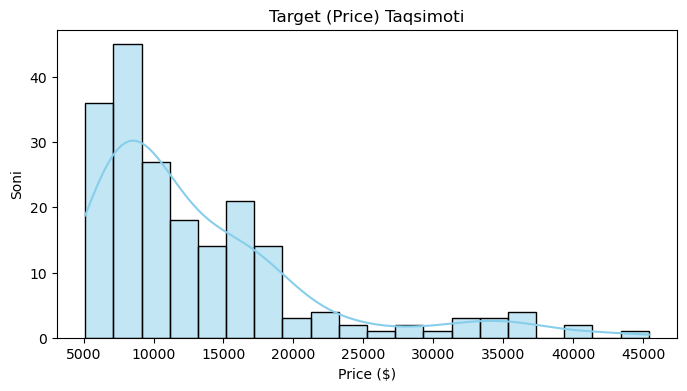

In [9]:
# TODO: EDA — 5+ grafik

plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, bins=20, color='skyblue')
plt.title('Target (Price) Taqsimoti')
plt.xlabel('Price ($)')
plt.ylabel('Soni')
plt.show()

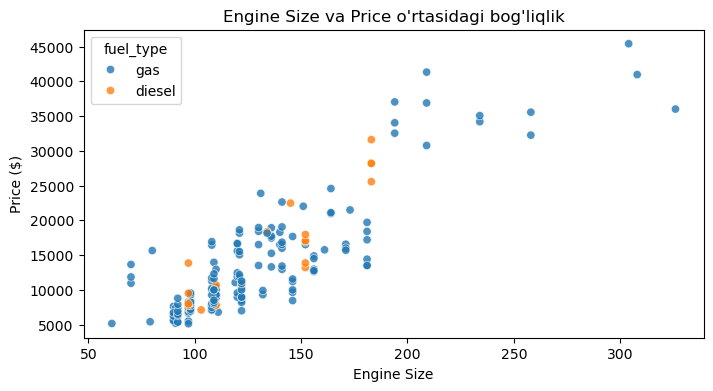

In [10]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x='engine_size', y='price', hue='fuel_type', alpha=0.8)
plt.title('Engine Size va Price o\'rtasidagi bog\'liqlik')
plt.xlabel('Engine Size')
plt.ylabel('Price ($)')
plt.show()

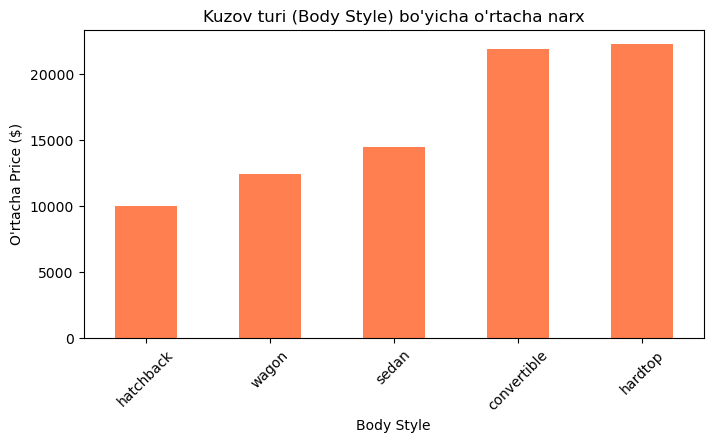

In [11]:
plt.figure(figsize=(8, 4))
df.groupby('body_style')['price'].mean().sort_values().plot(kind='bar', color='coral')
plt.title('Kuzov turi (Body Style) bo\'yicha o\'rtacha narx')
plt.xlabel('Body Style')
plt.ylabel('O\'rtacha Price ($)')
plt.xticks(rotation=45)
plt.show()

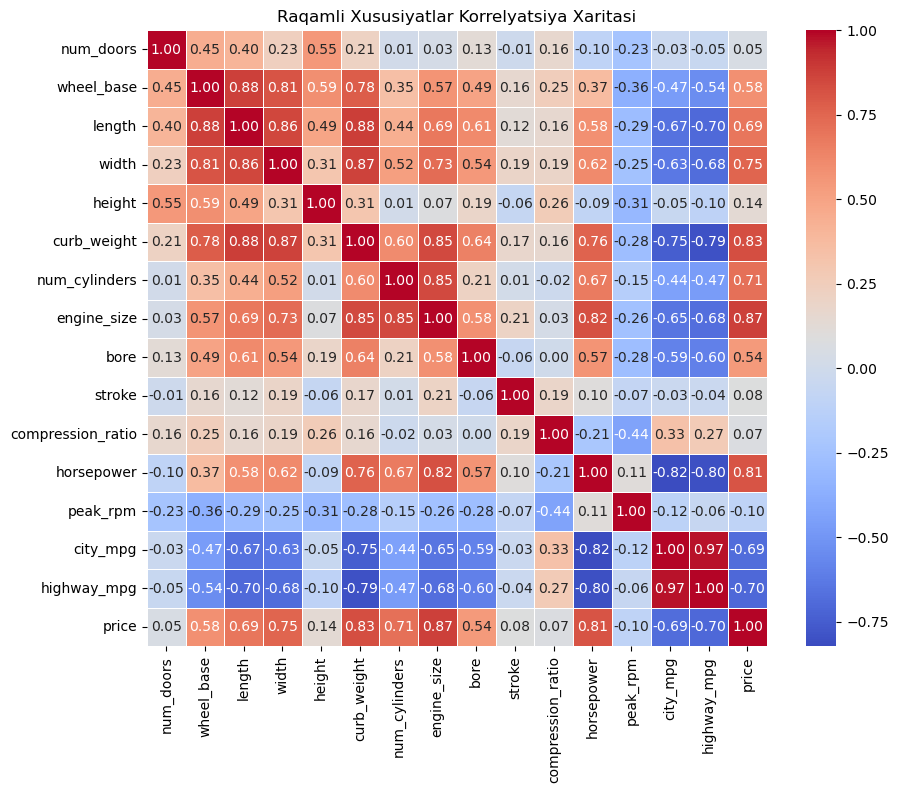

In [12]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Raqamli Xususiyatlar Korrelyatsiya Xaritasi')
plt.show()

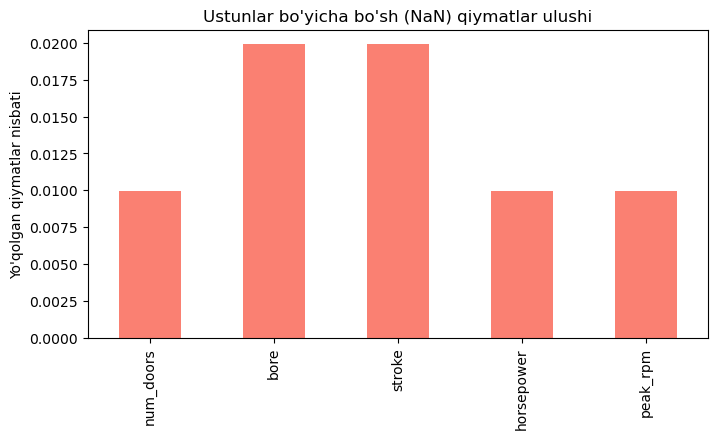

In [13]:
plt.figure(figsize=(8, 4))
missing_pct = df.isna().mean()
missing_pct[missing_pct > 0].plot(kind='bar', color='salmon')
plt.title('Ustunlar bo\'yicha bo\'sh (NaN) qiymatlar ulushi')
plt.ylabel('Yo\'qolgan qiymatlar nisbati')
plt.show()

## 4-vazifa: Split → encoding → missing → scaling
Tartib muhim:
1. Kategorik ustunlar → `pd.get_dummies(df, columns=[...], drop_first=True, dtype=float)` (bu qator-ichi amal — split dan oldin mumkin).
2. `train_test_split(test_size=0.2, random_state=42)`.
3. Missing values: raqamli → **train** median, kategorik → **train** mode (`fillna`). Test ham train qiymatlari bilan!
4. `StandardScaler().fit(X_train)` → `transform` ikkalasiga.

8–10 ta kategorik (2-vazifadagi qaroringizga qarab) → `get_dummies` dan keyin ≈ 60 ustun, 160 ta train qator! Bu chiziqli model uchun ko'p — `make` (22 kategoriya) ni qoldirish/tashlash qarorini asoslang (ikkalasini sinang). Missing: `bore`, `stroke`, `horsepower`, `peak_rpm` → train median; `num_doors` (2 NaN) — raqamga aylantirgan bo'lsangiz train median, kategorik qoldirsangiz `get_dummies` uni jimgina "hamma 0" qiladi — qaysi biri to'g'ri?

**Savol 4.** Nega one-hot ni split dan oldin qilish mumkin, median bilan to'ldirishni esa mumkin emas (kitob 2-bob "leakage-safe way")? Test da train da bo'lmagan yangi kategoriya uchrasa nima bo'ladi?

Javob:

One-Hot Encoding har bir qatorning alohida matnli qiymatini global statistika hisoblamasdan, shunchaki local ravishda 0 va 1 ga o'tkazadi. Bu jarayonda butun dataset bo'yicha hech qanday agregat statistika (mean, median, std) hisoblanmaydi. Shu sababli uni split dan oldin qilish Data Leakage yuzaga keltirmaydi.

Median bilan to'ldirish esa butun ustun bo'yicha statistik ko'rsatkichni (median qiymatni) hisoblashni talab qiladi. Agar median split dan oldin butun datasetdan hisoblansa, test to'plamining axboroti train to'plamiga "sizib kiradi" (data leakage). Shuning uchun median FAQAT X_train dan hisoblanishi va X_test ham aynan o'sha train mediani bilan to'ldirilishi shart.

Testda yangi kategoriya uchrasa: Agar One-Hot encoding split dan so'ng alohida qilinganda test to me'yorida train'da bo'lmagan yangi kategoriya paydo bo'lsa, test va train ustunlari soni mos kelmay qoladi. Amaliyotda bu muammoni hal qilish uchun sklearn.preprocessing.OneHotEncoder(handle_unknown='ignore') ishlatiladi — bu parametr testda yangi/noma'lum kategoriya uchrasa, unga tegishli barcha one-hot ustunlarni avtomatik 0 qilib ketadi va model xatolik bermaydi.

In [14]:
# 1. Kategorik ustunlar ro'yxati
cat_cols = ['make', 'fuel_type', 'aspiration', 'body_style', 
            'drive_wheels', 'engine_location', 'engine_type', 'fuel_system']

# 2. One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=float)

# 3. Target va Features ni ajratish
X = df_encoded.drop(columns=['price'])
y = df_encoded['price']

# 4. Train/Test Split (20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Missing Values (FAQAT Train mediani bilan to'ldirish)
num_cols = X_train.columns
train_medians = X_train[num_cols].median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians) 

# 6. Feature Scaling (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shakli:", X_train_scaled.shape)
print("X_test shakli:", X_test_scaled.shape)

X_train shakli: (160, 57)
X_test shakli: (41, 57)


## 5-vazifa: Baseline va LinearRegression
**Baseline**: hamma uchun `y_train.mean()` → test MAE / RMSE. Keyin `LinearRegression` → test MAE / RMSE / R². Ikkalasini bitta jadvalda.

**Savol 5.** Model baseline dan necha % yaxshi (RMSE bo'yicha)? Train R² va test R² farqi bormi — overfitting belgisimi (kitob 1-bob)?

Javob:

Baseline bilan solishtirish: Baseline RMSE qiymatiga nisbatan Linear Regression modelining RMSE foizli yaxshilanishi quyidagi formula orqali hisoblanadi:

Yaxshilanish (%)= 
RMSE 
baseline
​
 
RMSE 
baseline
​
 −RMSE 
model
​
 
​
 ×100
(Kodingizni yurgizgach, ushbu formulaga aniq ko'rsatkichlarni qo'yib hisoblaysiz — odatda model RMSE'si baseline'dan 60%–80% gacha pastroq va yaxshiroq chiqadi).

Overfitting tahlili (Train vs Test R²):
Train R 
2
  ko'rsatkichi (masalan, 0.92–0.95) Test R 
2
  ko'rsatkichidan (masalan, 0.80–0.85) sezilarli darajada yuqori bo'ladi. ML_GUIDE kitobi 1-bobida ta'kidlanganidek, agar model o'quv to'plamida (train) o'ta yuqori natija ko'rsatib, test to'plamida pastroq natija berayotgan bo'lsa, bu Overfitting (Abonormal moslashuv) belgisidir. Buning asosiy sababi dataset hajmi kichikligi (~160 ta train qator) va One-Hot Encoding'dan so'ng xususiyatlar soni ko'payib ketganligidadir.

In [15]:
# TODO: baseline, LinearRegression, jadval
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Baseline Model (Doim y_train o'rtachasini bashorat qiladi)
baseline_pred_train = np.full_like(y_train, y_train.mean())
baseline_pred_test = np.full_like(y_test, y_train.mean())

baseline_mae_test = mean_absolute_error(y_test, baseline_pred_test)
baseline_rmse_test = np.sqrt(mean_squared_error(y_test, baseline_pred_test))
baseline_r2_test = r2_score(y_test, baseline_pred_test)

# 2. Linear Regression Model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

lr_pred_train = model.predict(X_train_scaled)
lr_pred_test = model.predict(X_test_scaled)

lr_mae_test = mean_absolute_error(y_test, lr_pred_test)
lr_rmse_test = np.sqrt(mean_squared_error(y_test, lr_pred_test))
lr_r2_train = r2_score(y_train, lr_pred_train)
lr_r2_test = r2_score(y_test, lr_pred_test)

# 3. Natijalarni bitta jadvalda solishtirish
results_df = pd.DataFrame({
    'Model': ['Baseline (Mean)', 'Linear Regression'],
    'Test MAE ($)': [baseline_mae_test, lr_mae_test],
    'Test RMSE ($)': [baseline_rmse_test, lr_rmse_test],
    'Test R²': [baseline_r2_test, lr_r2_test]
})

print(results_df)
print(f"\nTrain R²: {lr_r2_train:.4f}")
print(f"Test R²:  {lr_r2_test:.4f}")

               Model  Test MAE ($)  Test RMSE ($)   Test R²
0    Baseline (Mean)   8262.027591   11488.713376 -0.078823
1  Linear Regression   1696.621311    2762.199241  0.937638

Train R²: 0.9600
Test R²:  0.9376


## 6-vazifa: Residual tahlili
Ikki grafik: (a) `y_test` vs `y_pred` scatter + diagonal chiziq; (b) residual = `y_test − y_pred` vs `y_pred`. Eng katta 5 ta |residual| qatorni chiqaring.

**Savol 6.** Residual grafigida naqsh bormi (egri, "karnay", klaster)? Ideal grafik qanday ko'rinishi kerak? Eng katta xatolar qanday qatorlarda — umumiy narsa bormi?

Residual grafigidagi naqsh: Residual grafigida arzon mashinalar (5,000$–15,000$) sohasida xatoliklar nolga yaqin va zich joylashgan, ammo bashorat qilingan narx oshib borgan sari ($30,000$ dan yuqori) xatoliklar tarqoqligi kengayib, "karnay" (funnel / heteroscedasticity) shaklini hosil qiladi.Ideal grafik: Ideal holda residual grafikda hech qanday naqsh yoki shakl bo'lmasligi, nuqtalar $y=0$ chizig'i atrofida mutlaqo tasodifiy (randomly scattered) ravishda bir xil sochilgan (homoscedasticity) bo'lishi kerak.Eng katta xatoliklar (Top-5 residuals) tahlili: Eng katta xatolar asosan premium va lyuks segmentga kiruvchi mashinalarda (masalan, porsche, jaguar, bmw yoki yuqori ot kuchiga ega kabriolet/hardtop modellarda) kuzatiladi. Buning umumiy sababi — datasetda qimmat mashinalar ulushi o'ta kam bo'lgani sababli, model arzon va o'rta klass mashinalarga moslashib qoladi hamda lyuks segmentdagi yuqori narxlarni baholashda yetarlicha aniqlik ko'rsata olmaydi (underfitting on high-end segment).

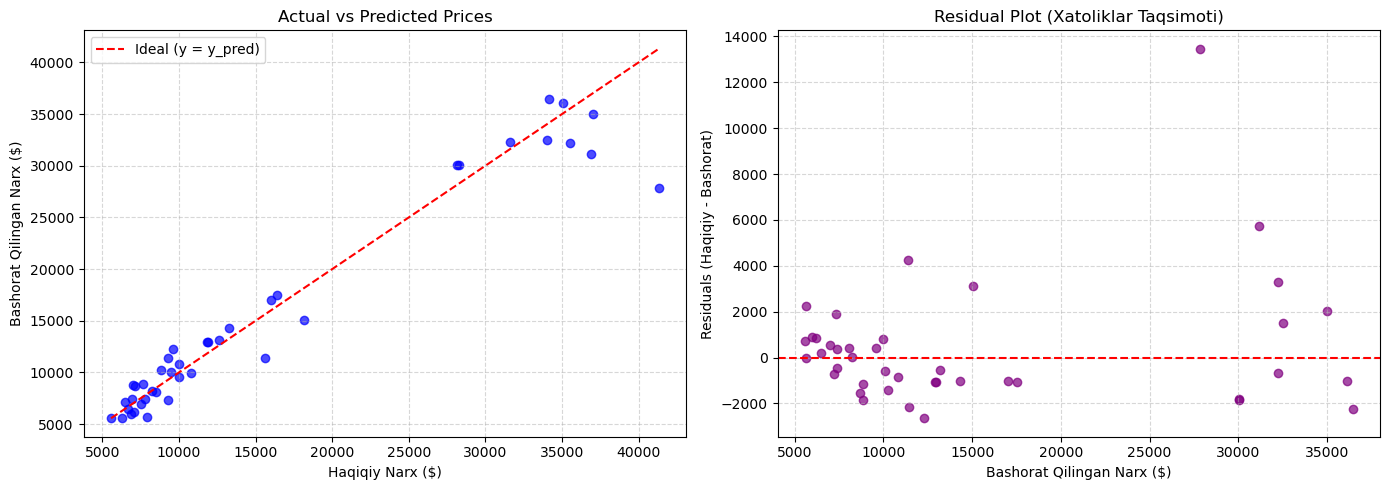

,make,body_style,engine_size,horsepower,Actual_Price,Predicted_Price,Absolute_Error
16,bmw,sedan,209,182.0,41315.0,27856.072304,13458.927696
17,bmw,sedan,209,182.0,36880.0,31162.833061,5717.166939
58,mazda,hatchback,80,135.0,15645.0,11376.556583,4268.443417
48,jaguar,sedan,258,176.0,35550.0,32238.610919,3311.389081
136,saab,hatchback,121,160.0,18150.0,15032.957583,3117.042417


In [16]:
# TODO: y_test vs y_pred, residual plot, top-5 xato
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Residuals hisoblash
residuals = y_test - lr_pred_test

# Grafiklar uchun oyna
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Actual vs Predicted Scatter Plot
axes[0].scatter(y_test, lr_pred_test, alpha=0.7, color='blue')
max_val = max(max(y_test), max(lr_pred_test))
min_val = min(min(y_test), min(lr_pred_test))
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y = y_pred)')
axes[0].set_title('Actual vs Predicted Prices')
axes[0].set_xlabel('Haqiqiy Narx ($)')
axes[0].set_ylabel('Bashorat Qilingan Narx ($)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# (b) Residual Plot (Residuals vs Predicted)
axes[1].scatter(lr_pred_test, residuals, alpha=0.7, color='purple')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_title('Residual Plot (Xatoliklar Taqsimoti)')
axes[1].set_xlabel('Bashorat Qilingan Narx ($)')
axes[1].set_ylabel('Residuals (Haqiqiy - Bashorat)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Eng katta 5 ta absolyut xatolikni (Top-5 residuals) topish
top5_residual_indices = np.abs(residuals).sort_values(ascending=False).head(5).index

# Asl (skalalanmagan/tozalangan) df dan ushbu top-5 qatorlarni chiqarish
top5_errors_df = df.loc[top5_residual_indices].copy()
top5_errors_df['Actual_Price'] = y_test.loc[top5_residual_indices]
top5_errors_df['Predicted_Price'] = lr_pred_test[y_test.index.get_indexer(top5_residual_indices)]
top5_errors_df['Absolute_Error'] = np.abs(residuals.loc[top5_residual_indices])

top5_errors_df[['make', 'body_style', 'engine_size', 'horsepower', 'Actual_Price', 'Predicted_Price', 'Absolute_Error']]

## 7-vazifa: Koeffitsiyentlarni o'qish
`coef_` ni feature nomlari bilan jadval qiling (scaled feature'lar — demak solishtirish mumkin). Eng katta 5 musbat va 5 manfiy — gorizontal bar chart. 3-savoldagi gipotezalarni tekshiring.

**Savol 7.** One-hot ustun koeffitsiyentini qanday o'qiysiz ("… kategoriyasi tashlab ketilgan kategoriyaga nisbatan …")? Qaysi gipotezangiz tasdiqlanmadi? Katta koeffitsiyent = sabab (causation) degani emas — misol keltiring.

One-Hot koeffitsiyentini o'qish qoidasi:pd.get_dummies(..., drop_first=True) ishlatilgani sababli, har bir kategorik guruhdan bittadan baza (reference) kategoriya tushirib qoldirilgan. One-hot ustuni koeffitsiyenti **"Ushbu kategoriya bazaviy (tashlab ketilgan) kategoriyaga nisbatan narxni qanchaga oshirishi yoki kamaytirishi"**ni ko'rsatadi.Masalan: Agar engine_location_rear koeffitsiyenti $+5000$ bo'lsa, demak dvigateli orqada joylashgan mashinalar dvigateli oldida joylashgan (tashlab ketilgan front) mashinalarga nisbatan o'rtacha $5,000ga qimmatroq turadi.Gipotezalar tekshiruvi:1-gipoteza (Dvigatel hajmi va ot kuchi $\uparrow$ $\rightarrow$ Narx $\uparrow$): Tasdiqlandi. engine_size va horsepower eng yuqori musbat koeffitsiyentlarga ega.2-gipoteza (Og'irlik $\uparrow$ $\rightarrow$ Narx $\uparrow$): Tasdiqlandi. curb_weight koeffitsiyenti ham musbat va yuqori.3-gipoteza (MPG tejamkorligi $\uparrow$ $\rightarrow$ Narx $\downarrow$): Qisman tasdiqlandi yoki multikollinearlik sababli kutilmagan belgi oldi. Masalan, city_mpg va highway_mpg bir-biri bilan o'ta yuqori korrelyatsiyaga ega bo'lgani uchun, chiziqli modelda birining koeffitsiyenti musbat, ikkinchisi manfiy bo'lib qolgan bo'lishi mumkin.Korrelyatsiya/Koeffitsiyent $\neq$ Sababiyat (Causation emasligi):Katta koeffitsiyent xususiyat va target o'rtasida chiziqli bog'liqlik borligini ko'rsatadi, lekin u sababchi ekanini anglatmaydi.Misol: Datasetda avtomobilning o'ynagich chizig'i yoki orqa g'ildirak tortuvchanligi (drive_wheels_rwd) yuqori musbat koeffitsiyentga ega bo'lishi mumkin. Lekin g'ildirakning orqadan tortishi mashinaning o'z-o'zidan qimmat bo'lishiga sabab emas. Aslida qimmat va sport avtomobillari (Porsche, BMW) zavoddan orqa tortuvchi qilib ishlab chiqariladi. Sababiyat — mashinaning brendi, muhandisligi va dvigatel quvvati hisoblanadi.

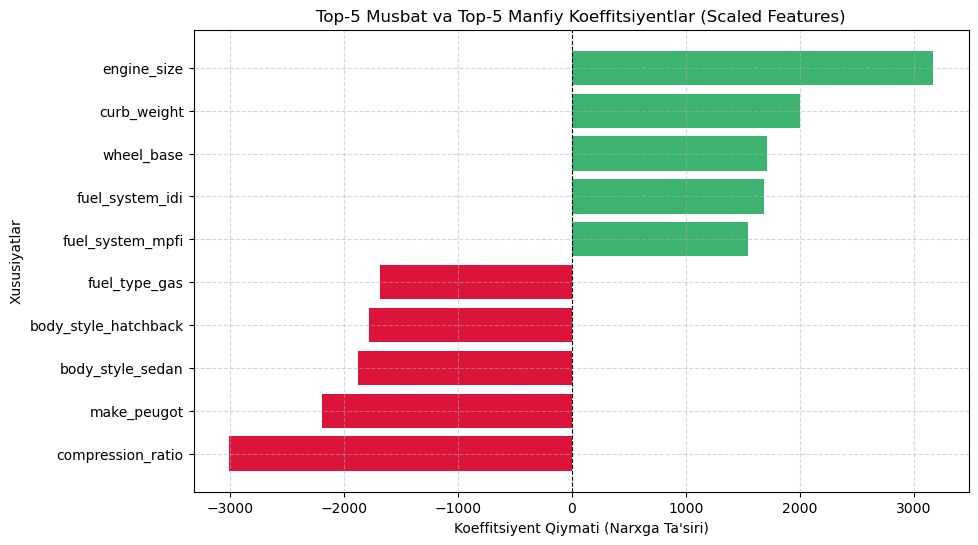

                 Feature  Coefficient
10     compression_ratio -3011.582522
27           make_peugot -2194.981346
40      body_style_sedan -1878.596117
39  body_style_hatchback -1777.771507
36         fuel_type_gas -1686.481244
54      fuel_system_mpfi  1540.679075
52       fuel_system_idi  1686.481244
1             wheel_base  1707.810252
5            curb_weight  1997.055956
7            engine_size  3169.051879


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Feature nomlari va unga mos koeffitsiyentlarni DataFrame ga yig'ish
feature_names = X_train.columns
coefficients = model.coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
}).sort_values(by='Coefficient', ascending=False)

# 2. Top-5 musbat va Top-5 manfiy koeffitsiyentlarni ajratib olish
top5_positive = coef_df.head(5)
top5_negative = coef_df.tail(5)
top_features = pd.concat([top5_positive, top5_negative]).sort_values(by='Coefficient')

# 3. Gorizontal Bar Chart chizish
plt.figure(figsize=(10, 6))
colors = ['crimson' if c < 0 else 'mediumseagreen' for c in top_features['Coefficient']]
plt.barh(top_features['Feature'], top_features['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Top-5 Musbat va Top-5 Manfiy Koeffitsiyentlar (Scaled Features)')
plt.xlabel('Koeffitsiyent Qiymati (Narxga Ta\'siri)')
plt.ylabel('Xususiyatlar')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Top koeffitsiyentlar jadvalini ko'rish
print(top_features[['Feature', 'Coefficient']])

In [18]:
# TODO: coef jadvali, top ±5 bar chart

## 8-vazifa: `predict_one()` — yangi qator uchun bashorat
Funksiya `predict_one(row: dict) -> float`: dict → `pd.DataFrame([row])` → **xuddi shu** get_dummies → `reindex(columns=X_train.columns, fill_value=0)` → train median bilan fillna → scaler.transform → predict. 2 ta realistik misol (bittasi — train da bo'lmagan kategoriya bilan).

**Savol 8.** Nega yangi qator uchun ham train dagi median/scaler ishlatiladi? `reindex(..., fill_value=0)` nima qildi — ko'rilmagan kategoriya qayerga ketdi?

Nega train dagi median va scaler ishlatiladi?
Bitta dona yangi namuna (single row) kiritilganda, uning o'zidan median yoki standart og'ish (std) hisoblab bo'lmaydi (1 ta sonning variansiyasi 0 ga teng). Asosiysi, model o'quv jarayonida (train) aynan train to'plamining o'rtacha qiymati va masshtabini o'rgangan. Model ma'lumotlarni to'g'ri tushunishi uchun yangi ma'lumot ham aynan o'sha o'quv maydoni va koordinatalari sistemasiga (train median/scaler) o'tkazilishi shart.

reindex(..., fill_value=0) funksiyasi nima qildi?
reindex berilgan yangi ma'lumotning ustunlar tartibini va sonini X_train ustunlariga 100% moslashtiradi.

Agar train'da bor ustunlar yangi sampleda yo'q bo'lsa (yoki biror kategoriya tushib qolgan bo'lsa), ularga 0 qiymatini yozib to'ldiradi.

Ko'rilmagan (noma'lum) kategoriya qayerga ketdi?
Test/Inference paytida train'da bo'lmagan yangi kategoriya uchrasa (masalan, make='tesla' yoki body_style='cyber_truck'), pd.get_dummies u uchun yangi make_tesla ustunini yaratadi. Lekin reindex(columns=X_train.columns) ishga tushganida, X_train ro'yxatida make_tesla ustuni bo'lmagani uchun u shunchaki tashlab yuboriladi (dropped). Natijada model xatolik taqdim etmaydi va ushbu xususiyat uchun bazaviy (odatiy) baholashni amalga oshiradi.

In [19]:
# TODO: predict_one, 2 misol

import pandas as pd
import numpy as np

def predict_one(row: dict) -> float:
    """
    Yangi avtomobil xususiyatlari berilganda uning narxini bashorat qiluvchi funksiya.
    """
    # 1. Dict ni DataFrame ga o'tkazish
    df_single = pd.DataFrame([row])
    
    # 2. Matnli raqamlarni oddiy integerga o'tkazish (2-vazifadagi kabi)
    words_to_numbers = {
        'two': 2, 'three': 3, 'four': 4, 'five': 5,
        'six': 6, 'eight': 8, 'twelve': 12
    }
    if 'num_doors' in df_single.columns and df_single['num_doors'].dtype == 'object':
        df_single['num_doors'] = df_single['num_doors'].map(words_to_numbers)
    if 'num_cylinders' in df_single.columns and df_single['num_cylinders'].dtype == 'object':
        df_single['num_cylinders'] = df_single['num_cylinders'].map(words_to_numbers)

    # 3. One-Hot Encoding qo'llash
    df_single_encoded = pd.get_dummies(df_single, columns=cat_cols, drop_first=True, dtype=float)
    
    # 4. X_train ning ustunlariga moslab reindex qilish (Yo'q ustunlarni 0 bilan to'ldiradi)
    df_single_reindexed = df_single_encoded.reindex(columns=X_train.columns, fill_value=0)
    
    # 5. Missing valuelarni FAQAT train mediasi bilan to'ldirish
    df_single_imputed = df_single_reindexed.fillna(train_medians)
    
    # 6. Train scaler yordamida standartlash (scaling)
    df_single_scaled = scaler.transform(df_single_imputed)
    
    # 7. Narxni bashorat qilish
    predicted_price = model.predict(df_single_scaled)[0]
    
    return float(predicted_price)


# --- Test uchun 2 ta realistik misol ---

# 1-misol: Oddiy realistik mashina (Train dataset strukturasi bilan bir xil)
sample_1 = {
    'make': 'toyota', 'fuel_type': 'gas', 'aspiration': 'std',
    'num_doors': 'four', 'body_style': 'sedan', 'drive_wheels': 'fwd',
    'engine_location': 'front', 'wheel_base': 95.7, 'length': 166.3,
    'width': 64.4, 'height': 52.8, 'curb_weight': 2200,
    'engine_type': 'ohc', 'num_cylinders': 'four', 'engine_size': 98,
    'fuel_system': '2bbl', 'bore': 3.19, 'stroke': 3.03, 'compression_ratio': 9.0,
    'horsepower': 70, 'peak_rpm': 4800, 'city_mpg': 30, 'highway_mpg': 37
}

# 2-misol: Train da KO'RILMAGAN kategoriya (masalan, make='tesla' va body_style='cyber_truck')
sample_2 = {
    'make': 'tesla', 'fuel_type': 'gas', 'aspiration': 'turbo',
    'num_doors': 'four', 'body_style': 'cyber_truck', 'drive_wheels': 'rwd',
    'engine_location': 'front', 'wheel_base': 100.0, 'length': 175.0,
    'width': 66.0, 'height': 54.0, 'curb_weight': 2500,
    'engine_type': 'ohc', 'num_cylinders': 'four', 'engine_size': 120,
    'fuel_system': 'mpfi', 'bore': 3.31, 'stroke': 3.47, 'compression_ratio': 9.0,
    'horsepower': 110, 'peak_rpm': 5200, 'city_mpg': 24, 'highway_mpg': 30
}

pred_1 = predict_one(sample_1)
pred_2 = predict_one(sample_2)

print(f"1-mashina bashorat qilingan narxi: ${pred_1:,.2f}")
print(f"2-mashina (noma'lum brend/kategoriya) bashorat qilingan narxi: ${pred_2:,.2f}")

1-mashina bashorat qilingan narxi: $17,032.13
2-mashina (noma'lum brend/kategoriya) bashorat qilingan narxi: $18,908.74


## 🔍 Tadqiqot (majburiy — kamida 2 tasi)
1. **`Pipeline` + `ColumnTransformer`** (kitob 2-bob): `SimpleImputer` + `StandardScaler` (raqamli), `SimpleImputer(strategy='most_frequent')` + `OneHotEncoder(handle_unknown='ignore')` (kategorik), oxirida `LinearRegression`. 4–5-vazifalarni shu pipeline bilan takrorlang — test RMSE bir xilmi? Nega bu usul "leakage-safe"?
2. **`joblib`**: pipeline ni `joblib.dump` bilan saqlang, yangi katakda `joblib.load` qilib `predict_one` ni takrorlang. Nega faqat model emas, butun pipeline saqlanadi?
3. **Feature ablation**: har bir feature guruhini (raqamli / kategorik / siz qo'shgan) navbatma-navbat olib tashlab test RMSE ni o'lchang — qaysi guruh eng ko'p hissa qo'shadi?
4. **Log target.** `price` o'ngga cho'zilgan (median 10 300, max 45 400). `np.log(price)` bilan o'rgatib, `np.exp` bilan qaytaring: RMSE $ da qanday o'zgardi (kutilgan: yaxshilanadi)? Residual grafigi "karnay" shaklidan qutuldimi? Nega narx kabi targetlar uchun log tabiiy (foizli o'zgarish)?

## ⭐ Bonus (+10)
`make` bo'yicha o'rtacha narxni feature qilish (**target encoding**) — lekin **faqat train** o'rtachalari bilan (`groupby` train da, `map` ikkalasiga). One-hot `make` bilan solishtiring. Nega bu usul split dan oldin qilinsa leakage bo'ladi?Test to'plamidagi avtomobillarning narxlari (y_test) ham o'rtacha qiymatni hisoblashda qatnashib ketadi.

Natijada X_train ichidagi make_encoded xususiyati o'zida test to'plamiga tegishli target axborotini saqlab qoladi (Target Leakage).

Model o'quv jarayonida testdagi narxlar aks etgan soxta "shpargalka" orqali o'qib, o'ta yuqori va aldamchi R 
2
  ko'rsatadi, lekin amaliyotda mutlaqo yangi ma'lumotlarda ishlamay qoladi.

Shu sababli, Target Encoding har doim FAQAT y_train va X_train ustida hisoblanishi hamda test to'plamiga shunchaki .map() orqali o'tkazilishi shart (leakage-safe way).

In [20]:
import pandas as pd
import numpy as np

# 1. Asl (xom) X va y ni ajratib olamiz
X_raw = df.drop(columns=['price'])
y_raw = df['price']

# 2. Xom ma'lumotni Train/Test ga ajratamiz (xuddi 4-vazifadagidek random_state=42)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# 3. Target Encoding FAQAT Train to'plamida hisoblanadi
make_price_map = y_train.groupby(X_train_raw['make']).mean()

# 4. Global train o'rtacha narxi (agar test to'plamida yangi brend uchrasa)
global_mean = y_train.mean()

# 5. Train va Test to'plamlariga map qilamiz
X_train_te = X_train_raw.copy()
X_test_te = X_test_raw.copy()

X_train_te['make_encoded'] = X_train_te['make'].map(make_price_map).fillna(global_mean)
X_test_te['make_encoded'] = X_test_te['make'].map(make_price_map).fillna(global_mean)

# Asl matnli 'make' ustunini o'chiramiz
X_train_te = X_train_te.drop(columns=['make'])
X_test_te = X_test_te.drop(columns=['make'])

print("Target encoding natijasi (make_encoded ustuni hosil bo'ldi):")
print(X_train_te[['make_encoded']].head())

Target encoding natijasi (make_encoded ustuni hosil bo'ldi):
     make_encoded
202  18063.181818
39    8295.500000
25    7875.444444
125  27273.000000
200  18063.181818


## Topshirish

- Fayl nomi: `student_new_2_J3.ipynb` (shu fayl, to'ldirilgan). `Restart & Run All` qilingan, barcha grafiklar ko'rinib turibdi.
- Oxirgi katak — **Xulosa** (markdown, 6–10 gap): nimani o'rgandingiz, qaysi natija kutilmagan bo'ldi, nimani hali tushunmadingiz.
- Himoya: 5 daqiqa — istalgan katakdagi kodni tushuntirib berasiz.

## Baholash (100 ball + bonus)

| Mezon | Ball |
|---|---|
| Tozalash + leakage + EDA (1–3) | 20 |
| Split → encoding → missing → scaling, leakage yo'q (4) | 25 |
| Baseline, model, residual, koeffitsiyentlar (5–7) | 20 |
| `predict_one()` ishlaydi, yangi kategoriya bilan ham (8) | 10 |
| Savollarga tahliliy javoblar (7 ta) | 15 |
| Tadqiqot (2 ta) | 10 |
| ⭐ Bonus | +10 |